# GRA: lion + cifar

project = ```GRA```, host = ```chewie```, device = ```cuda:0```

## Goals:

Test these Lion extensions:

**relativistic**

On `ImageNet`

In [1]:
# HIDE CODE


project_name = '_GRA'


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, project_name))
from utils.plotting import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: chewie

## Main

In [3]:
from optimzers import *
from test.test import *

### CIFAR10

`batch_size=256`

In [4]:
cfg = TrainConfig(
    dataset='CIFAR10',
    # dataset='ImageNet32',
    batch_size=256,
    epochs=1000,
    device=device,
    data_on_device=True,
    verbose=True,
    amp=False,
)

In [5]:
lr = 1e-3
beta1 = 0.8
kws = dict(lr=lr, betas=(beta1, 0.99), use_curvature=False)


experiments = [Experiment(
    f"Rel Lion — lr={lr},b1={beta1},mass={m}",
    make_opt(RelativisticLion, mass=m, **kws),
) for m in [100]]

experiments.extend([Experiment(
    f"Adam — lr={lr},b1={b1}",
    make_opt(torch.optim.Adam, lr=1e-3, betas=(b1, 0.99)),
) for b1 in [0.8, 0.9]])

print(experiments)

[
    Experiment(
        name='Rel Lion — lr=0.001,b1=0.8,mass=100',
        opt_fn=<function make_opt.<locals>._fn at 0x748540fb8220>
    ),
    Experiment(name='Adam — lr=0.001,b1=0.8', opt_fn=<function make_opt.<locals>._fn at 0x748540fb8180>),
    Experiment(name='Adam — lr=0.001,b1=0.9', opt_fn=<function make_opt.<locals>._fn at 0x748540fb8400>)
]

In [6]:
results = run_experiments(experiments, cfg=cfg, seeds=[0, 1, 2, 3, 4])

--- Training (CIFAR10) ---

Model: ConvNet | seed=0
Optimizer: RelativisticLion

RelativisticLion (
Parameter Group 0
    betas: (0.8, 0.99)
    lr: 0.001
    mass: 100
    use_curvature: False
    weight_decay: 0.0
)

Epoch    1/1000:  Train Loss 1.0094  |  Test Acc 76.31%

Epoch   10/1000:  Train Loss 0.0840  |  Test Acc 87.07%

Epoch   20/1000:  Train Loss 0.0295  |  Test Acc 87.73%

...

Epoch  970/1000:  Train Loss 0.0159  |  Test Acc 88.18%

Epoch  980/1000:  Train Loss 0.0131  |  Test Acc 88.17%

Epoch  990/1000:  Train Loss 0.0159  |  Test Acc 88.09%

Epoch 1000/1000:  Train Loss 0.0196  |  Test Acc 88.27%

Finished in 2907.2s

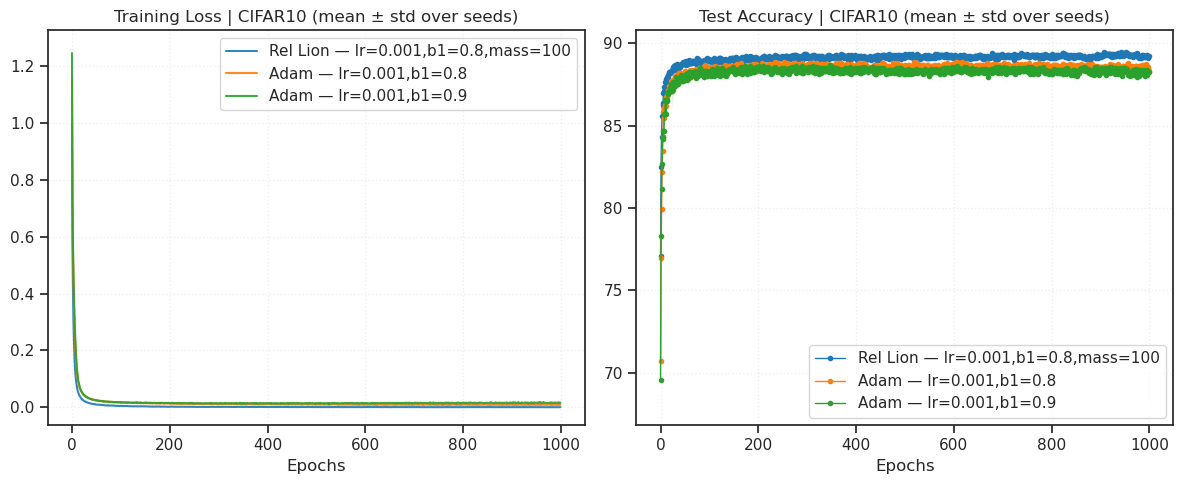

In [9]:
plot_results(results, title="CIFAR10 (mean ± std over seeds)")

In [10]:
avg_scores = {k: np.round(d['test_acc'].squeeze()[-5:].mean(), decimals=2) for k, d in results.items()}
avg_scores = dict(sorted(avg_scores.items(), key=lambda t: t[1]))
avg_scores

{'Adam — lr=0.001,b1=0.9': 88.22,
 'Adam — lr=0.001,b1=0.8': 88.45,
 'Rel Lion — lr=0.001,b1=0.8,mass=100': 89.08}